In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns

In [3]:
df=pd.read_csv('train.csv')

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df=df.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [7]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [8]:
df['Is_alone']=df['SibSp']+df['Parch']+1

In [9]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Is_alone
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,NaN,1,2,23.4500,S,4
889,1,1,male,26.0,0,0,30.0000,C,1


In [10]:
df=df.drop(columns=['SibSp','Parch'])

In [11]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,Is_alone
0,0,3,male,22.0,7.2500,S,2
1,1,1,female,38.0,71.2833,C,2
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,2
4,0,3,male,35.0,8.0500,S,1
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,1
887,1,1,female,19.0,30.0000,S,1
888,0,3,female,NaN,23.4500,S,4
889,1,1,male,26.0,30.0000,C,1


In [12]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
Is_alone      0
dtype: int64

In [13]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [14]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    2
Is_alone    0
dtype: int64

In [15]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
df.shape

(891, 7)

In [17]:
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [18]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,Is_alone
0,0,3,0,22.0,7.2500,0,2
1,1,1,1,38.0,71.2833,1,2
2,1,3,1,26.0,7.9250,0,1
3,1,1,1,35.0,53.1000,0,2
4,0,3,0,35.0,8.0500,0,1
...,...,...,...,...,...,...,...
886,0,2,0,27.0,13.0000,0,1
887,1,1,1,19.0,30.0000,0,1
888,0,3,1,28.0,23.4500,0,4
889,1,1,0,26.0,30.0000,1,1


In [19]:
import seaborn as sns

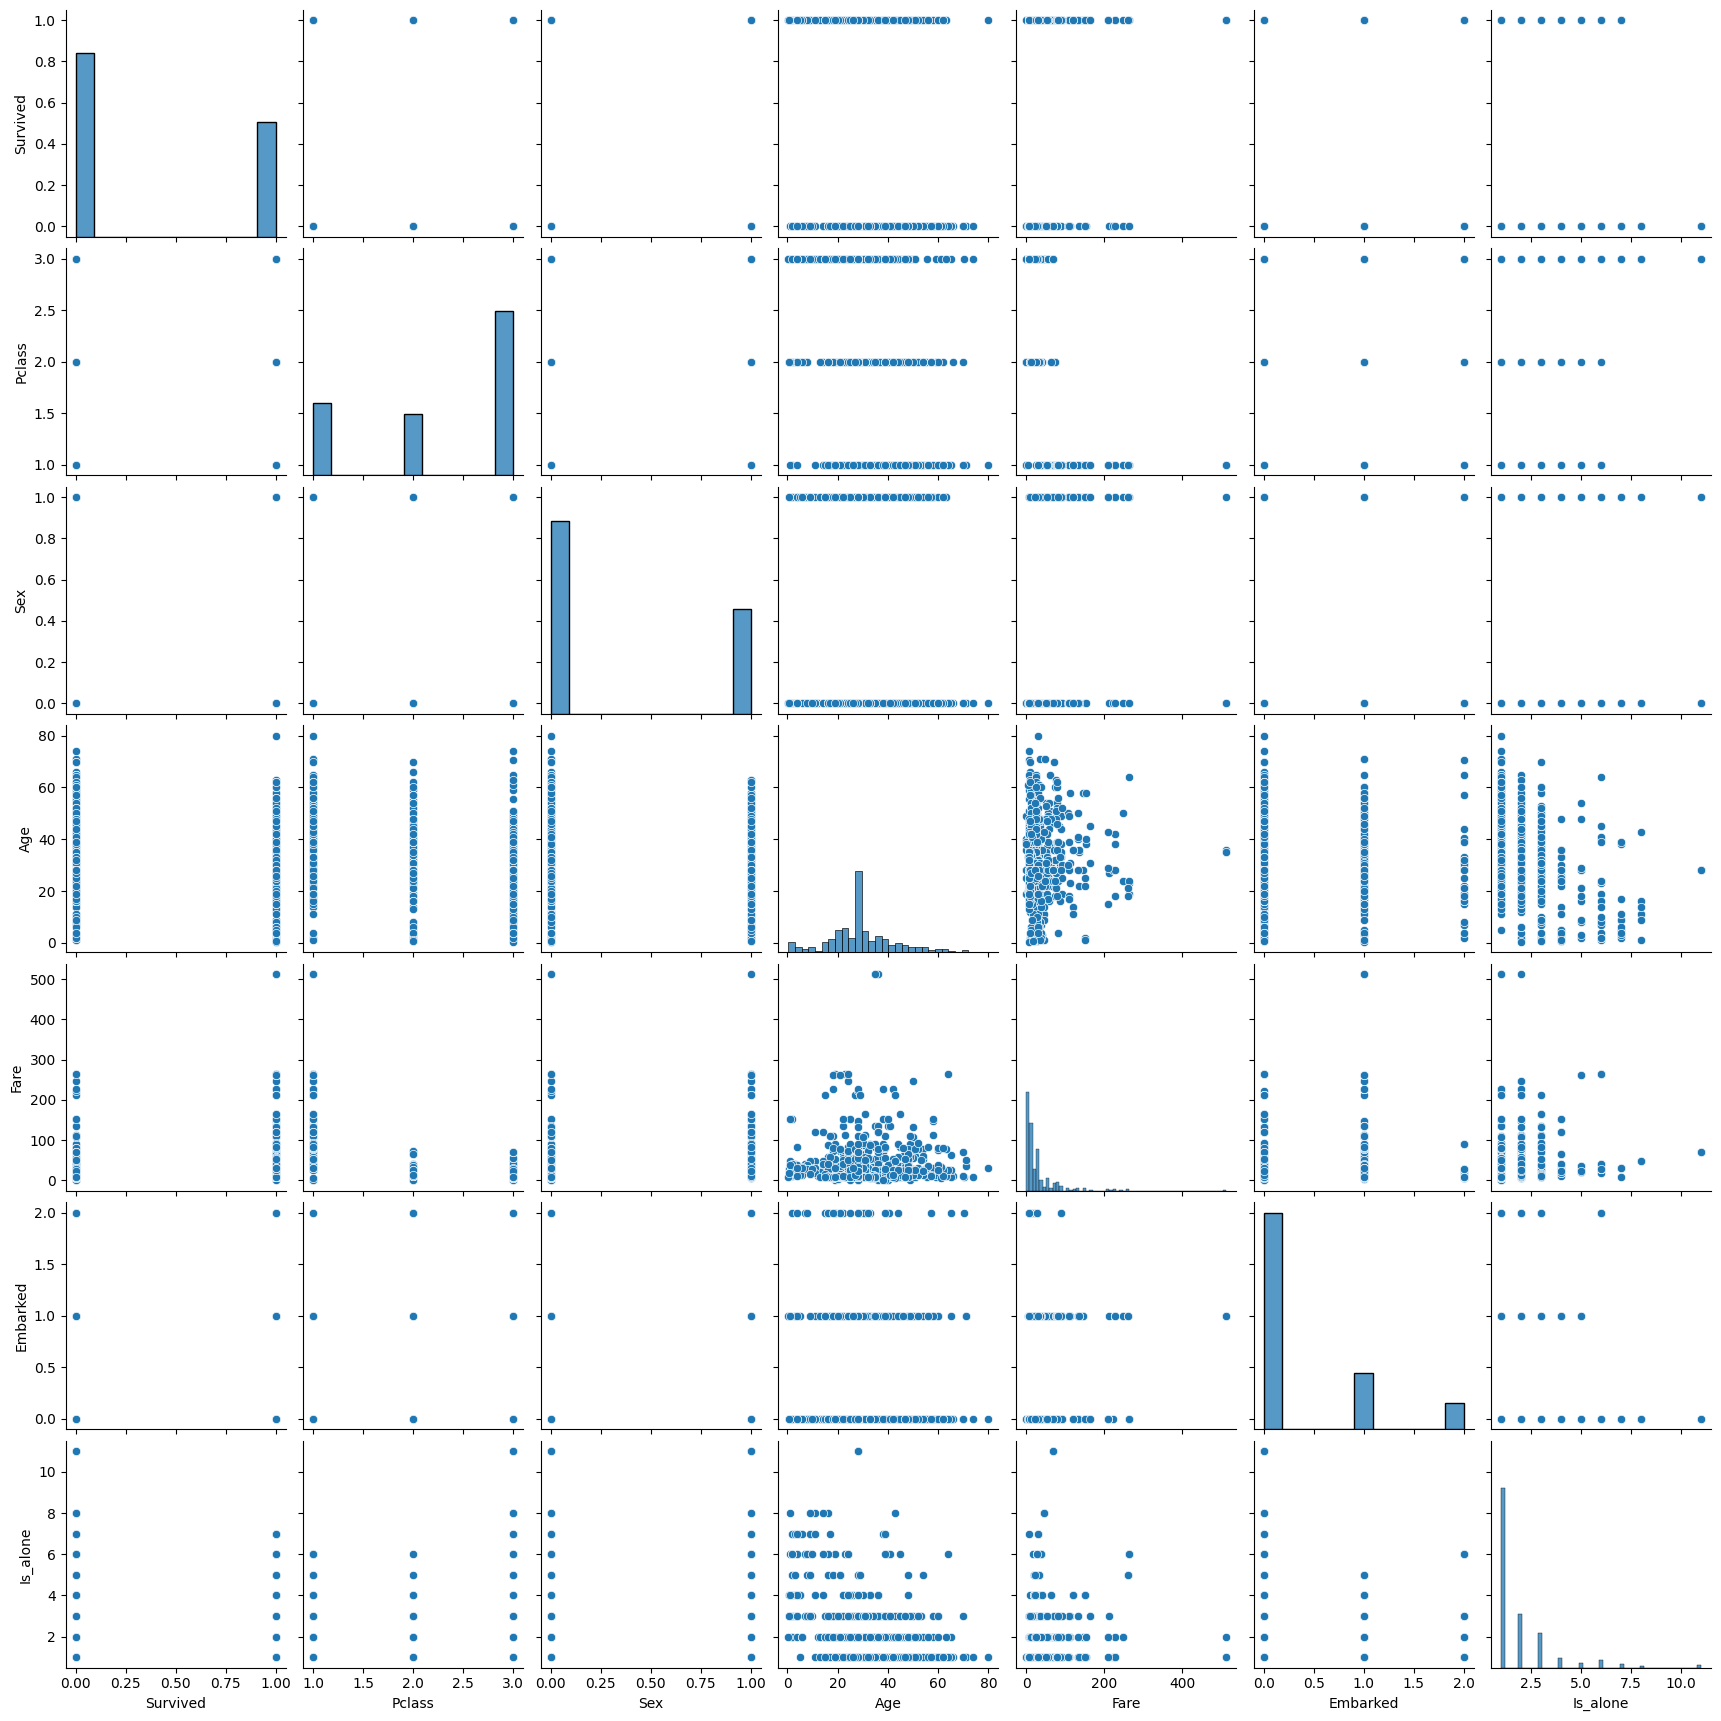

In [20]:
sns.pairplot(df)

<Axes: >

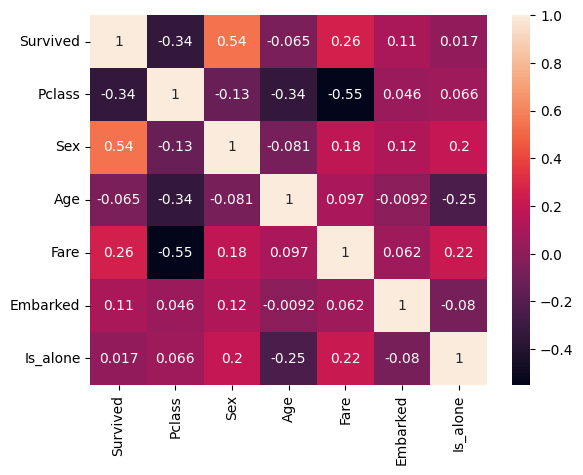

In [21]:
sns.heatmap(df.corr(),annot=True)

In [22]:
df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [23]:
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
X=df.drop('Survived',axis=1)

In [33]:
y=df['Survived']

In [34]:
X.shape

(891, 6)

In [35]:
y.shape

(891,)

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [37]:
scaler=StandardScaler()

In [39]:
X_train_scaled=scaler.fit_transform(X_train)

In [40]:
X_test_scaled=scaler.transform(X_test)

In [41]:
models={
    "logistic":LogisticRegression(),
    "KNN":KNeighborsClassifier(n_neighbors=5),
    "DT":DecisionTreeClassifier(),
    "NB":GaussianNB(),
    "SVM":SVC(kernel="rbf",random_state=42)
}

In [42]:
from sklearn.metrics import r2_score,accuracy_score,classification_report,confusion_matrix,f1_score

In [43]:
results=[]

In [44]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({
        'Name':name,
        'Accuracy':round(acc,4),
        'f1':round(f1,4)
    })
    

In [45]:
ans=pd.DataFrame(results)

In [46]:
ans

,Name,Accuracy,f1
0,logistic,0.7989,0.7188
1,KNN,0.7877,0.7077
2,DT,0.8212,0.7612
3,NB,0.7877,0.7206
4,SVM,0.8156,0.7179


In [47]:
import joblib 

In [48]:
joblib.dump(models["SVM"],"SVM.pkl")

['SVM.pkl']

In [49]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [50]:
joblib.dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']